## Table Of Content
1. Convolution layers
2. Max Pooling layers
3. OverFitting and UnderFitting
4. Data Agumentation



## Convolution layers

1. Visulization [https://poloclub.github.io/cnn-explainer/]
2. Viz 2 [https://adamharley.com/nn_vis/cnn/3d.html]

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import  Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import fashion_mnist
import  matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)
from dataclasses import dataclass

In [2]:
(train_imgs , train_lab) , (test_imgs , test_lab) = fashion_mnist.load_data()
print(train_imgs.shape)
print(test_imgs.shape)

(60000, 28, 28)
(10000, 28, 28)


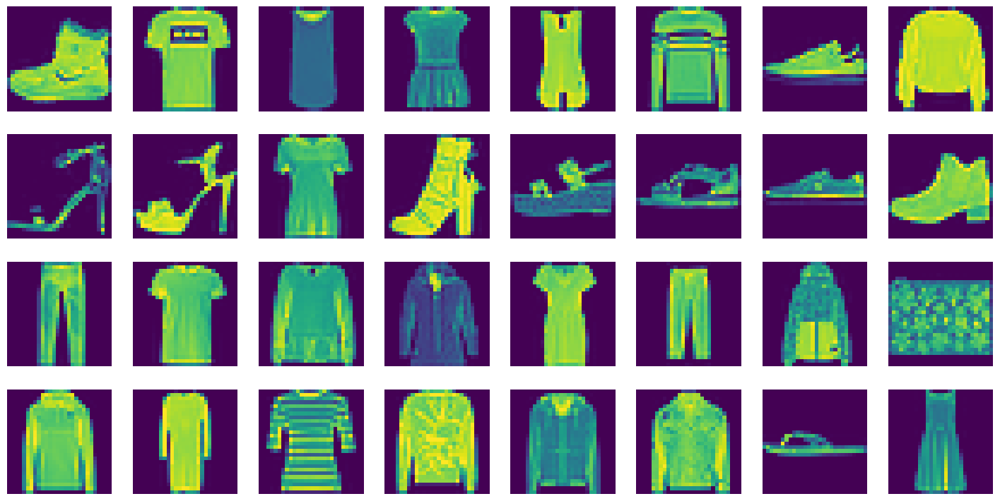

In [3]:
plt.figure(figsize=(18, 9))

num_rows = 4
num_cols = 8

# plot each of the images in the batch and the associated ground truth labels.
for i in range(num_rows*num_cols):
    ax = plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(train_imgs[i,:,:])
    plt.axis("off")

### Dataset Preprocessing

We normalize the image data to the range [0,1]. This is very common when working with image data which helps the model train more efficiently. We also convert the integer labels to one-hot encoded labels, as discussed in previous videos.

In [4]:
# Normalize images to the range [0, 1].
train_imgs = train_imgs.astype("float32") / 255
test_imgs  = test_imgs.astype("float32") / 255

# Change the labels from integer to categorical data.
print('Original (integer) label for the first training sample: ', train_lab[0])

# Convert labels to one-hot encoding.
train_lab = to_categorical(train_lab)
test_lab  = to_categorical(test_lab)

print('After conversion to categorical one-hot encoded labels: ', train_lab[0])


Original (integer) label for the first training sample:  9
After conversion to categorical one-hot encoded labels:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Dataset and Training Configuration Parameters

In [5]:
@dataclass(frozen =True)
class DataConfig:
  NUM_Of_Class : int = 10
  IMG_HIGH : int = 28
  IMG_WIDTH : int = 28
  NUM_CHANNELS : int = 1




In [6]:
@dataclass(frozen=True)
class TraiConfg:
  EPOCHS: int = 10
  BATCH_SIZE : int = 32
  LEARNING_RATE : float = 0.001

In [7]:
class CNN_ONLY:
  def __init__(self , input_shape = (28,28,1)):
    self.model = Sequential()
    self.input_shape = input_shape
    # Conv Block 1  with 32 filters
    self.model.add(Conv2D(filters = 32 , kernel_size = 3 , padding = 'same' , activation = 'relu'  , input_shape = self.input_shape))

    # Conv Block 1  with 64 filters
    self.model.add(Conv2D(filters = 64 , kernel_size = 3 , padding = 'same' , activation = 'relu' ) )

    # flatten
    self.model.add(Flatten())
    # Dense
    self.model.add(Dense(512, activation = 'relu'))
    self.model.add(Dense(10 , activation = 'softmax'))


  def get_model(self):
    return self.model





In [8]:
CNN_model = CNN_ONLY()
modelV1 = CNN_model.get_model()

C:\Users\trdaxy\.venvs\skyx-tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
modelV1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,714,570 (98.09 MB)

 Trainable params: 25,714,570 (98.09 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
modelV1.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'],
             )

In [11]:
hist1 = modelV1.fit(x = train_imgs ,
                   y = train_lab ,
                   batch_size = TraiConfg.BATCH_SIZE,
                   epochs = TraiConfg.EPOCHS,
                   verbose =  1 ,
                   validation_split = .3,
                   validation_data=(test_imgs, test_lab))

Epoch 1/10


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 1:05:22 2s/step - accuracy: 0.1250 - loss: 2.3151

   2/1875 ━━━━━━━━━━━━━━━━━━━━ 10:09 325ms/step - accuracy: 0.1094 - loss: 6.8277

   3/1875 ━━━━━━━━━━━━━━━━━━━━ 10:21 332ms/step - accuracy: 0.0833 - loss: 5.6134

   4/1875 ━━━━━━━━━━━━━━━━━━━━ 10:36 340ms/step - accuracy: 0.0859 - loss: 4.8372

...

1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9963 - loss: 0.0122

1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9963 - loss: 0.0122

1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9963 - loss: 0.0122

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9963 - loss: 0.0122

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 375s 200ms/step - accuracy: 0.9963 - loss: 0.0122 - val_accuracy: 0.9144 - val_loss: 0.7818



## Plot the Training Results

The function below is a convenience function to plot training and validation losses and training and validation accuracies. It has a single required argument which is a list of metrics to plot.

In [12]:
modelV1.save('CNN_Only.keras')

In [13]:
test_loss, test_acc = modelV1.evaluate(test_imgs, test_lab)
print(f"Test accuracy: {test_acc*100:.3f}")

  1/313 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8750 - loss: 1.1636

  5/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9187 - loss: 0.8571

  9/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9271 - loss: 0.6591

 13/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9159 - loss: 0.7223

 18/313 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9097 - loss: 0.7121

...

304/313 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9145 - loss: 0.7818

308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9148 - loss: 0.7776

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9144 - loss: 0.7818

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9144 - loss: 0.7818


Test accuracy: 91.440

## MAX Pooling

![MAX Pooling](../assets/reference_images/max_pooling_diagram.png)
![MAX Pooling + CNN](../assets/reference_images/conv2d_layers_diagram.png)

In [14]:
# MAX Pooling + CNN Model
class CNN_MAXPooling:
  def __init__(self , input_shape = (28,28,1)):
    self.model = Sequential()
    self.input_shape = input_shape
    # Conv Block 1  with 32 filters
    self.model.add(Conv2D(filters = 32 , kernel_size = 3 , padding = 'same' , activation = 'relu'  , input_shape = self.input_shape))
    self.model.add(Conv2D(filters = 32 , kernel_size = 3 , padding = 'same' , activation = 'relu'))
    self.model.add(MaxPooling2D(pool_size = (2,2)))
    # Conv Block 2  with 64 filters
    self.model.add(Conv2D(filters = 64 , kernel_size = 3 , padding = 'same' , activation = 'relu' ) )
    self.model.add(Conv2D(filters = 64 , kernel_size = 3 , padding = 'same' , activation = 'relu' ) )
    self.model.add(MaxPooling2D(pool_size= (2,2)))

    # flatten
    self.model.add(Flatten())
    # Dense
    self.model.add(Dense(512, activation = 'relu'))
    self.model.add(Dense(10 , activation = 'softmax'))


  def get_model(self):
    return self.model


In [15]:
CNN_MAXPool_model = CNN_MAXPooling()
modelV2 = CNN_MAXPool_model.get_model()

In [16]:
modelV2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,676,266 (6.39 MB)

 Trainable params: 1,676,266 (6.39 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
modelV2.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'],
             )

In [18]:
hist2 = modelV2.fit(x = train_imgs ,
                   y = train_lab ,
                   batch_size = TraiConfg.BATCH_SIZE,
                   epochs = TraiConfg.EPOCHS,
                   verbose =  1 ,
                   validation_split = .3,
                   validation_data=(test_imgs, test_lab))

Epoch 1/10


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 25:15 808ms/step - accuracy: 0.1562 - loss: 2.3080

   4/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.2109 - loss: 2.2688   

   7/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.2589 - loss: 2.2278

  10/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.3000 - loss: 2.0996

...

1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9709 - loss: 0.0836

1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9709 - loss: 0.0837

1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9709 - loss: 0.0837

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9709 - loss: 0.0837

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9709 - loss: 0.0837 - val_accuracy: 0.9200 - val_loss: 0.4106


In [19]:
modelV2.save('CNN_MaxPooling.keras')

In [20]:
test_loss, test_acc = modelV2.evaluate(test_imgs, test_lab)
print(f"Test accuracy: {test_acc*100:.3f}")

  1/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9375 - loss: 0.8770

 10/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9531 - loss: 0.2616 

 18/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9271 - loss: 0.3973

 27/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9306 - loss: 0.3986

 35/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9259 - loss: 0.3975

...

288/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9196 - loss: 0.4118

298/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9200 - loss: 0.4092

308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9199 - loss: 0.4103

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9200 - loss: 0.4106


Test accuracy: 92.000


### Discussion of Results
1. It looks like this model is significantly improved! The training accuracy is very high, and the validation accuracy has improved as well. This is a great result, as all we had to do was swap in a new model.

You may have noticed the validation accuracy jumping around. This is an indication that our model is still not generalizing perfectly. Fortunately, there's more that we can do. Let's talk about it in the next lecture.

![Overfitting vs Underfitting](../assets/overfitting_vs_underfitting.png)

# Data Agumantation
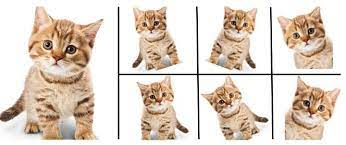

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [22]:
datagen =  ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            vertical_flip=True
        )


# Update the shape of input data
train_imgs2 = np.expand_dims(train_imgs, axis=-1)  # Expand dimensions to include the channel
test_imgs2 = np.expand_dims(test_imgs, axis=-1)  # Expand dimensions to include the channel

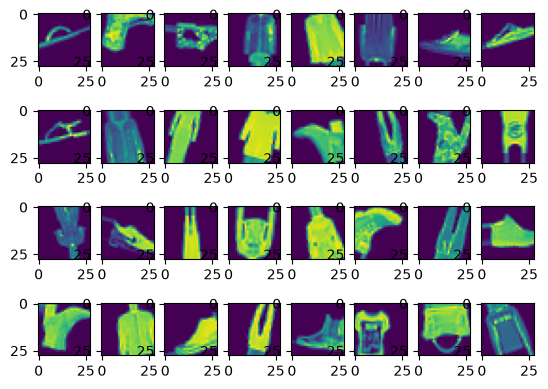

In [23]:
img_iter = datagen.flow(train_imgs2, train_lab, batch_size=32)

x, y = next(img_iter)
fig, ax = plt.subplots(nrows=4, ncols=8)
for i in range(32):
    image = x[i]
    ax.flatten()[i].imshow(np.squeeze(image))
plt.show()

### Fitting the Data to the Generator

In [24]:
datagen.fit(train_imgs2)

In [25]:
CNN_MAXPool_DataAug_model = CNN_MAXPooling()
modelV3 = CNN_MAXPool_DataAug_model.get_model()

C:\Users\trdaxy\.venvs\skyx-tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
modelV3.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'],
             )

### Training with Augmentation
When using an image data generator with Keras, a model trains a bit differently: instead of just passing the`x_train` and `y_train` datasets into the model, we pass the generator in, calling the generator's flow method. This causes the images to get augmented live and in memory right before they are passed into the model for training.

Generators can supply an indefinite amount of data, and when we use them to train our data, we need to explicitly set how long we want each epoch to run, or else the epoch will go on indefinitely, with the generator creating an indefinite number of augmented images to provide the model.

Run the following cell to see the results. The training will take longer than before, which makes sense given we are now training on more data than previously:

In [27]:
hist3 = modelV3.fit(img_iter,
                   epochs = TraiConfg.EPOCHS,
                   verbose =  1 ,
                   validation_split = .3,
                   validation_data=(test_imgs, test_lab))

Epoch 1/10


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 29:10 934ms/step - accuracy: 0.0938 - loss: 2.2991

   3/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.1458 - loss: 2.3476   

   5/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.1187 - loss: 2.3391

   7/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.1429 - loss: 2.3255

...

1865/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8499 - loss: 0.4305

1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8499 - loss: 0.4306

1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8499 - loss: 0.4305

1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8500 - loss: 0.4303

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.8500 - loss: 0.4303 - val_accuracy: 0.8457 - val_loss: 0.4881


In [28]:
# Save Model
modelV3.save('CNN_Pooling_DataAug_model.keras')

## Discussion of Results
You will notice that the validation accuracy is higher, and more consistent. This means that our model is no longer overfitting in the way it was; it generalizes better, making better predictions on new data.